In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("src/")
import src.preprocessing.data_loading as data_loading
import numpy as np
from matplotlib import pyplot as plt
import itertools
from functools import partial

from analysis.hit_rate_analysis import (
    seq_contains_12ca5_motif,
    seq_contains_mdm2_motif,
)
from analysis.scatter_plots import (
    plot_relations,
    plot_fancy_hexbin_relations
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
protein_of_interest = "MDM2"
other_protein = "12ca5"
hit_func = seq_contains_mdm2_motif if protein_of_interest == "MDM2" else seq_contains_12ca5_motif

X, y_raw, peptides, FEATURE_LIST = data_loading.build_joint_dataset(
    er_datafile =f"{protein_of_interest}_merged_ER.csv",
    volcano_datafile="12ca5-MDM2-R3.csv",
    protein_of_interest=protein_of_interest, 
    other_protein=other_protein
)

jointlibShape:  (63982, 31)
Unnamed: 0x                                                      0
Peptide                                                    KEDLRDY
MDM2 sum_x                                                0.000207
MDM2 sum_y                                                0.000169
MDM2 sum                                                  0.000061
ER                                                        1.769216
Lengthx                                                          7
is_dyax                                                      False
is_llex                                                      False
c_cntx                                                           0
Pro2Vecx         [0.6172555904835056, 0.6483376217869719, 0.700...
RAAx             [1e-08, 0.02564103, 0.03205128, 0.63461538, 0....
propx            [[-1.5, 5.7, 3.0, 0.018, 11.3, 49.5, 0.219, 2....
onehotx          [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Unnamed: 0                        

/Users/stephen/mambaforge/envs/BiLSTM_new/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:618: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [5]:
volcano_datafile="12ca5-MDM2-R3.csv"

In [ ]:
y_raw

## What is the ER / FC / P value Data Distribution Look Like?

In [ ]:
plot_relations(x_idx=1, y_idx=0, datapoints=y_raw, ordering=None, all_positives=None, kind='scatter')
plot_relations(x_idx=1, y_idx=2, datapoints=y_raw, ordering=None, all_positives=None, kind='scatter')
plot_relations(x_idx=0, y_idx=2, datapoints=y_raw, ordering=None, all_positives=None, kind='scatter')


## Where are the true hits (defined by motif) in our dataset?

(-11.26699745539576, 12.802835987110129, -0.8329379238887278, 27.369964117469774)


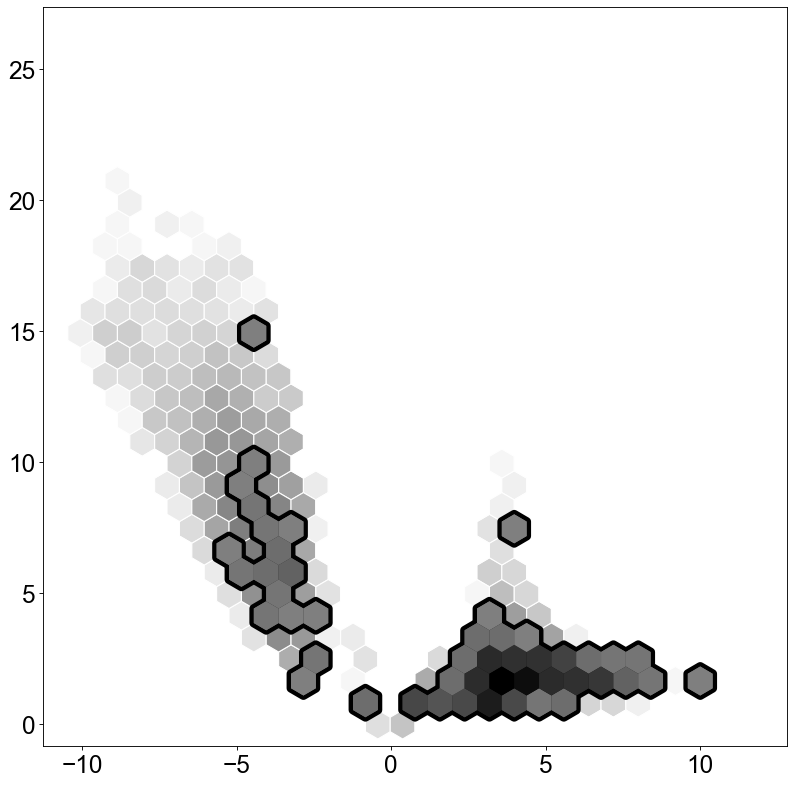

(-11.26699745539576, 12.802835987110129, -12.424972942105276, 18.0343835663439)


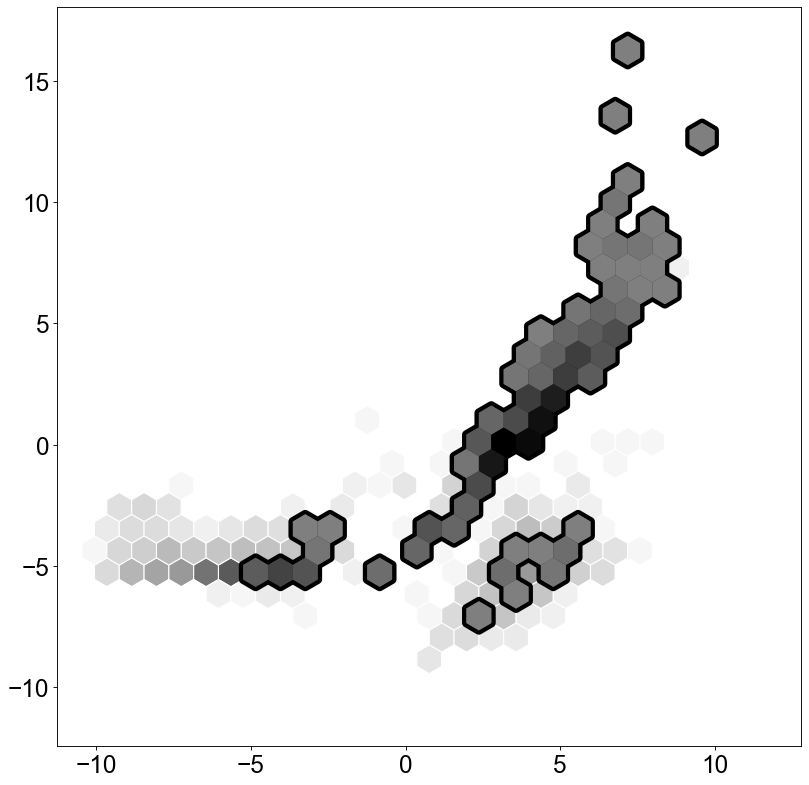

(-0.8329379238887278, 27.369964117469774, -12.424972942105276, 18.0343835663439)


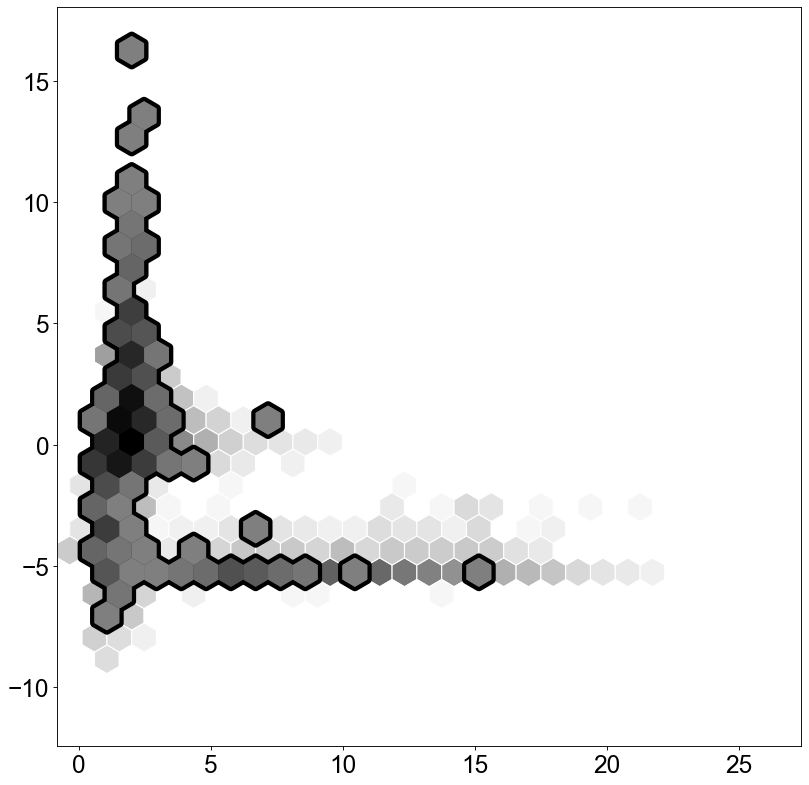

In [ ]:
hypothetical_best_ordering = np.array([ 1.0 if hit_func(pep) else 0.0 for pep in peptides])


plot_fancy_hexbin_relations(
    1,
    0,
    datapoints=y_raw,
    ordering=hypothetical_best_ordering,
    all_positives=None,
    title='',
    plot_labels=False,
)
plot_fancy_hexbin_relations(
    1,
    2,
    datapoints=y_raw,
    ordering=hypothetical_best_ordering,
    all_positives=None,
    title='',
    plot_labels=False,
)
plot_fancy_hexbin_relations(
    0,
    2,
    datapoints=y_raw,
    ordering=hypothetical_best_ordering,
    all_positives=None,
    title='',
    plot_labels=False,
)

